In [1]:
# Import modules

import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle
import random
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
from tensorflow import keras
from tensorflow.keras import Sequential, layers
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Flatten, Conv2D, Dense, BatchNormalization, MaxPooling2D, Dropout, GlobalAveragePooling2D, RandomRotation, RandomFlip, RandomSharpness, RandomPosterization
from sklearn.metrics import classification_report, f1_score
from tensorflow.keras.utils import to_categorical
#print(tf.__version__)

2025-08-30 17:43:44.161111: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-30 17:43:44.260652: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756565024.286642   29075 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756565024.295431   29075 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-30 17:43:44.389724: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [3]:
# Create file

def prepare_file(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [5]:
# Prepare labels and categories

class_file = prepare_file('./assets/cifar/meta')
class_categs = dict([(l[0], l[1].decode('utf-8')) for l in list(enumerate(class_file[b'coarse_label_names']))])
class_labels = dict([(l[0], l[1].decode('utf-8')) for l in list(enumerate(class_file[b'fine_label_names']))])

In [6]:
# Prepare train datas

x_train_file = prepare_file('./assets/cifar/train')
x_train = x_train_file[b'data']
y_train = np.array(x_train_file[b'fine_labels'])
y_categ = np.array(x_train_file[b'coarse_labels'])

In [7]:
# Prepare test datas

x_test_file = prepare_file('./assets/cifar/test')
x_test = x_test_file[b'data']
y_test = np.array(x_test_file[b'fine_labels'])

In [8]:
# Reshape and normalize

def reshape_and_normalize(X):
    return X.reshape(len(X), 3, 32, 32).transpose(0, 2, 3, 1) / 255.0

In [9]:
# Split train and validate data

X_train, X_valid, Y_train, Y_valid = train_test_split(
    x_train,
    y_train,
    train_size=0.8,
    stratify=y_train,
    random_state=42
)

In [10]:
# Reshape datas

X_train = reshape_and_normalize(X_train)
X_valid = reshape_and_normalize(X_valid)
X_test = reshape_and_normalize(x_test)

In [11]:
# Labels to one hot encoding matrix

Y_train = to_categorical(Y_train, 100)
Y_valid = to_categorical(Y_valid, 100)
Y_test = to_categorical(y_test, 100)

In [12]:
# Test variables

print(Y_train)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [13]:
# View labels and categories

df = pd.DataFrame(zip(y_train, y_categ))
df = df \
    .drop_duplicates(subset=[0], keep='first', inplace=False) \
    .rename(columns={0: 'Label ID', 1: 'Category ID'}) \
    .sort_values(by='Label ID')

df['Label Name'] = df.apply(lambda r: class_labels[r['Label ID']], axis=1)
df['Category Name'] = df.apply(lambda r: class_categs[r['Category ID']], axis=1)
df = df[['Label ID', 'Label Name', 'Category ID', 'Category Name']]
df

,Label ID,Label Name,Category ID,Category Name
2,0,apple,4,fruit_and_vegetables
4,1,aquarium_fish,1,fish
202,2,baby,14,people
342,3,bear,8,large_carnivores
102,4,beaver,0,aquatic_mammals
...,...,...,...,...
94,95,whale,0,aquatic_mammals
11,96,willow_tree,17,trees
17,97,wolf,8,large_carnivores
58,98,woman,14,people


In [14]:
# Get specific images

def get_specific_images(label='', interval=tuple()):
    label_id = df[df['Label Name'] == label]
    label_id = label_id['Label ID'].tolist()[0]
    label_ids = Y_train
    if interval:
        label_ids = label_ids[interval[0]:interval[1]]
    return [i for i, j in enumerate(label_ids) if np.argmax(j) == label_id]

In [15]:
# Map labels and categories

label_ids = df['Label ID'].tolist()
categ_ids = df['Category ID'].tolist()
dict_label_categ = dict(zip(label_ids, categ_ids))

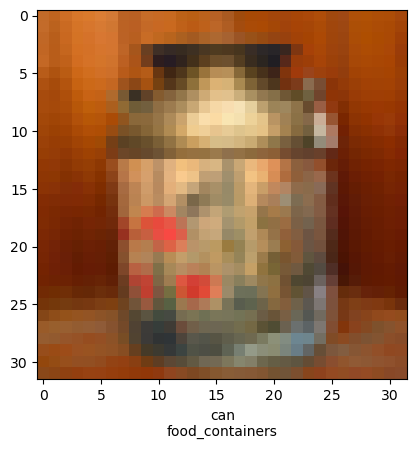

In [16]:
# Create random image
int_random = random.randint(0, len(X_train))
y_value = np.argmax(Y_train[int_random])
plt.imshow(X_train[int_random])
plt.xlabel('%s\n%s' % (class_labels[y_value], class_categs[dict_label_categ[y_value]]))
plt.show()

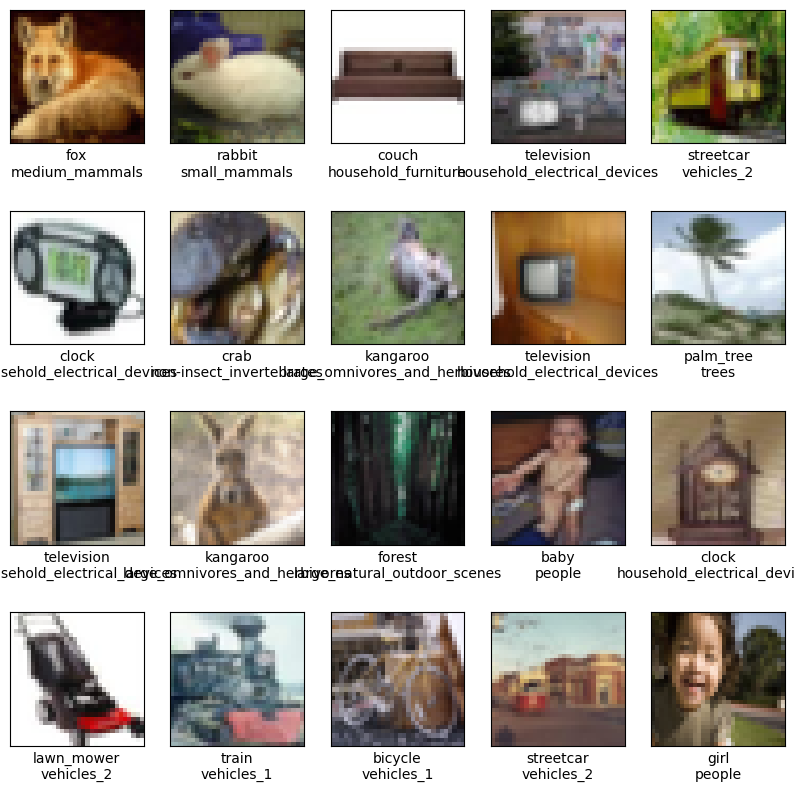

In [17]:
# Plot categories

def plot_images(images=X_train, labels=Y_train, label='', interval=tuple(), grid_size=(4, 5)):

    if label:
        label = get_specific_images(label, interval)

    if interval:
        images = images[interval[0]:interval[1]]
        labels = labels[interval[0]:interval[1]]

    plt.figure(figsize=(10, 10))
    for i in range(grid_size[0] * grid_size[1]):
        try:
            index = label[i] if label else i
            y_value = np.argmax(labels[index])
            image = images[index]
        except:
            break

        plt.subplot(grid_size[0], grid_size[1], i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(image)
        plt.xlabel('%s\n%s' % (class_labels[y_value], class_categs[dict_label_categ[y_value]]))
    plt.show()
plot_images()

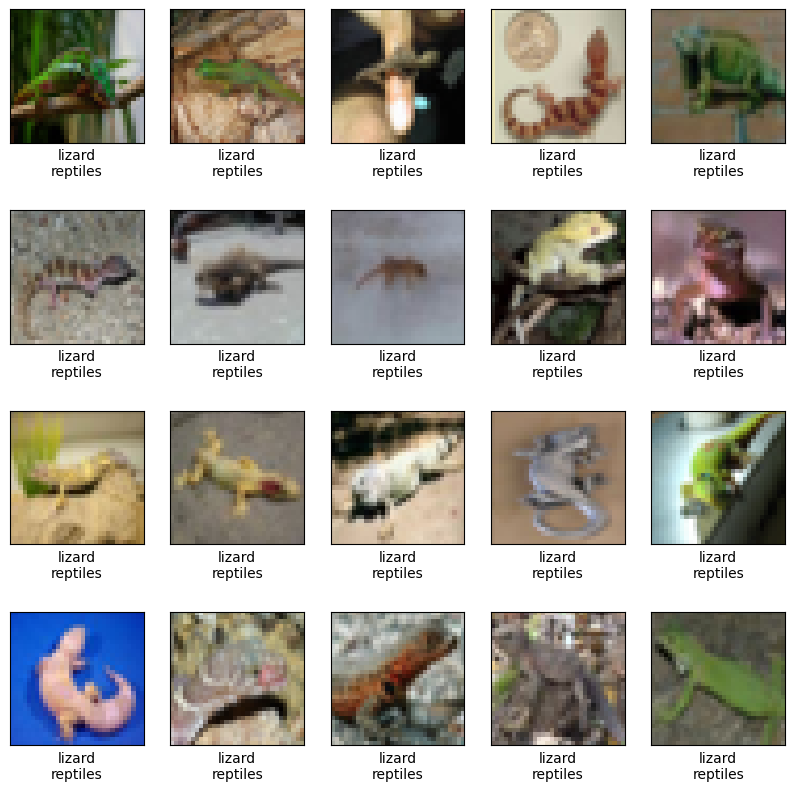

In [18]:
# Plot spesific categories

plot_images(label='lizard')

In [19]:
# Prepare enhancing worst classes

def augment_classes(images, labels, names, factor=3):
    enhanced_images = []
    enhanced_labels = []

    for name in names:
        ids = get_specific_images(name)
        
        if len(ids) > 0:
            print(f'{name} sınıfı için veri artırma ({len(ids)} örnek)')

            for _ in range(factor):
                augmented_batch = []
                augmented_label = []
                
                for i in ids:
                    augmented = images[i].copy()

                    # Random processes
                    if np.random.random() > 0.5:
                        augmented = tf.image.random_flip_left_right(augmented[np.newaxis, ...])[0]
                    if np.random.random() > 0.5:
                        augmented = tf.image.random_flip_up_down(augmented[np.newaxis, ...])[0]
                    if np.random.random() > 0.5:
                        augmented = tf.image.random_brightness(augmented, 0.2)
                    if np.random.random() > 0.5:
                        augmented = tf.image.random_contrast(augmented, 0.8, 1.2)
                    if np.random.random() > 0.5:
                        rotation_layer = RandomRotation(0.1)
                        augmented = rotation_layer(augmented[np.newaxis, ...])[0]
                    augmented_batch.append(augmented)
                    augmented_label.append(labels[i])

                enhanced_images.extend(augmented_batch)
                enhanced_labels.extend(augmented_label)
    
    return np.array(enhanced_images), np.array(enhanced_labels)

In [82]:
# Enhance worst classes

worst_classes = [
    'otter'
    #'otter', 'seal', 'squirrel',
    #'rabbit', 'man', 'mouse', 
    #'beaver', 'bear', 'shrew',
    #'woman', 'lobster', 'crocodile', 
    #'turtle', 'possum', 'tulip'
]

X_train_enhanced, Y_train_enhanced = augment_classes(
    X_train,
    Y_train,
    worst_classes,
    factor=2
)

print(f'\nVeri boyutu: {len(X_train)} -> {len(X_train) + len(X_train_enhanced)}')
print(f'Artış oranı: {(len(X_train) + len(X_train_enhanced)) / len(X_train):.2f}x')

otter sınıfı için veri artırma (400 örnek)

Veri boyutu: 40000 -> 40800
Artış oranı: 1.02x


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12549073994159698..0.818090558052063].


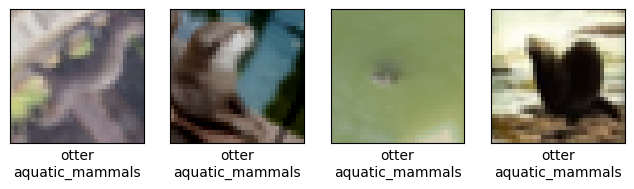

In [84]:
plot_images(images=X_train_enhanced, labels=Y_train_enhanced, label='otter')

In [ ]:
# Reassign values

X_train = np.array([*X_train, *X_train_enhanced])
Y_train = to_categorical(np.array([*Y_train, *Y_train_enhanced]), 100)

In [ ]:
# Recompute class weights

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(Y_train),
    y=Y_train
)
class_weight = dict(enumerate(class_weights))
print(class_weight)
for class_name in worst_classes:
    w = list(class_labels.values()).index(class_name)
    if w in class_weight:
        class_weight[w] *= 1.5

In [ ]:
# Prepare model

inputs = Input(shape=(32, 32, 3))

# Data augmentation
stack = RandomFlip("horizontal")(inputs)
stack = RandomRotation(0.05)(stack)
stack = RandomSharpness((0.4, 0.4))(stack)
stack = RandomPosterization(1)(stack)

# Block 1
stack = Conv2D(96, (3,3), activation='relu', padding='same')(stack)
stack = BatchNormalization()(stack)
stack = Conv2D(96, (3,3), activation='relu', padding='same')(stack)
stack = BatchNormalization()(stack)
stack = MaxPooling2D((2,2))(stack)
stack = Dropout(0.25)(stack)

# Block 2
stack = Conv2D(192, (3,3), activation='relu', padding='same')(stack)
stack = BatchNormalization()(stack)
stack = Conv2D(192, (3,3), activation='relu', padding='same')(stack)
stack = BatchNormalization()(stack)
stack = MaxPooling2D((2,2))(stack)
stack = Dropout(0.35)(stack)

# Block 3
stack = Conv2D(384, (3,3), activation='relu', padding='same')(stack)
stack = BatchNormalization()(stack)
stack = Conv2D(384, (3,3), activation='relu', padding='same')(stack)
stack = BatchNormalization()(stack)
stack = MaxPooling2D((2,2))(stack)
stack = Dropout(0.45)(stack)

# Block 4
stack = Conv2D(512, (3,3), activation='relu', padding='same')(stack)
stack = BatchNormalization()(stack)
stack = Conv2D(512, (3,3), activation='relu', padding='same')(stack)
stack = BatchNormalization()(stack)
stack = GlobalAveragePooling2D()(stack)
stack = Dropout(0.5)(stack)

# Dense
stack = Dense(1024, activation='relu')(stack)
stack = BatchNormalization()(stack)
stack = Dropout(0.6)(stack)

stack = Dense(512, activation='relu')(stack)
stack = BatchNormalization()(stack)
stack = Dropout(0.5)(stack)

# Output
outputs = Dense(100, activation='softmax')(stack)

model = keras.Model(inputs, outputs)

In [ ]:
# Compile model

model.compile(
    optimizer=Adam(learning_rate=0.0008),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Callbacks for model training

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    mode='max'
)

model_checkpoint = ModelCheckpoint(
    filepath="checkpoints/best_model.keras",
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    mode='max',
    verbose=1
)

In [ ]:
# Prepare datasets

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train))
train_dataset = train_dataset.shuffle(15000).batch(128).prefetch(tf.data.AUTOTUNE)

valid_dataset = tf.data.Dataset.from_tensor_slices((X_valid, Y_valid))
valid_dataset = valid_dataset.batch(128).prefetch(tf.data.AUTOTUNE)

In [ ]:
# Train model

model_trained = model.fit(
    train_dataset,
    epochs=120,
    validation_data=valid_dataset,
    #class_weight=class_weight,
    callbacks=[early_stopping, model_checkpoint, reduce_lr],
    verbose=1
)

In [20]:
# Load model

model = load_model('model0.keras')

I0000 00:00:1756565175.434670   29075 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [23]:
# Evaluate model for validation data

model.evaluate(X_valid, Y_valid)

313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.9999 - loss: 6.5301e-04


[0.0006530098617076874, 0.9998999834060669]

In [21]:
# Evaluate model for test data

model.evaluate(X_test, Y_test)

I0000 00:00:1756565204.197083   35362 service.cc:148] XLA service 0x723e9c001e30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756565204.197172   35362 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-08-30 17:46:44.248900: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1756565204.527472   35362 cuda_dnn.cc:529] Loaded cuDNN version 90101
2025-08-30 17:46:45.029279: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_628', 20 bytes spill stores, 20 bytes spill loads

2025-08-30 17:46:45.346713: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_628',

  1/313 ━━━━━━━━━━━━━━━━━━━━ 38:09 7s/step - accuracy: 0.7812 - loss: 1.9774

I0000 00:00:1756565210.201742   35362 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7091 - loss: 2.0454

2025-08-30 17:47:21.881389: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.63GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-08-30 17:47:21.881546: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.82GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 104ms/step - accuracy: 0.7121 - loss: 2.0070


[2.0069704055786133, 0.7121000289916992]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


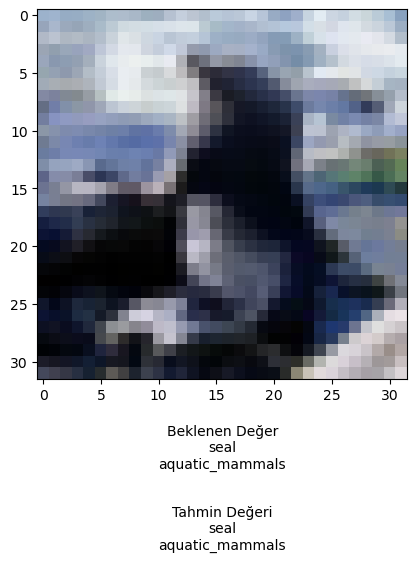

In [27]:
# Test model

int_random = random.randint(0, len(Y_test))
y_pred = model.predict(X_test[int_random:int_random+1])
y_pred = y_pred.argmax(axis=1).tolist()[0]
y_value = np.argmax(Y_test[int_random])
#print('Tahmin Değeri: %s' % y_pred)
plt.imshow(X_test[int_random,:])
plt.xlabel('\nBeklenen Değer\n%s\n%s\n\n\nTahmin Değeri\n%s\n%s' % (
    class_labels[y_value],
    class_categs[dict_label_categ[y_value]],
    class_labels[y_pred],
    class_categs[dict_label_categ[y_pred]],
))
plt.show()

In [28]:
# Create evaluation table

label_test = Y_test.argmax(axis=1)
label_pred = model.predict(X_test).argmax(axis=1)

name_label =  [] 
name_pred = []
for i in range(10000):
  name_label.append(class_labels[label_test.tolist()[i]])
  name_pred.append(class_labels[label_pred.tolist()[i]])

df_pred = pd.DataFrame({
  "Label ID": label_test, 
  "Label Name": name_label,
  "Predicted ID" : label_pred,
  "Predicted Name" : name_pred
})
df_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 87ms/step


,Label ID,Label Name,Predicted ID,Predicted Name
0,49,mountain,12,bridge
1,33,forest,33,forest
2,72,seal,55,otter
3,51,mushroom,51,mushroom
4,71,sea,71,sea
...,...,...,...,...
9995,83,sweet_pepper,83,sweet_pepper
9996,14,butterfly,63,porcupine
9997,51,mushroom,51,mushroom
9998,42,leopard,42,leopard


In [30]:
# Classification report for prediction table

print(classification_report(df_pred["Label Name"], df_pred["Predicted Name"]))

               precision    recall  f1-score   support

        apple       0.87      0.88      0.88       100
aquarium_fish       0.80      0.80      0.80       100
         baby       0.64      0.61      0.63       100
         bear       0.49      0.51      0.50       100
       beaver       0.58      0.56      0.57       100
          bed       0.82      0.67      0.74       100
          bee       0.74      0.78      0.76       100
       beetle       0.77      0.67      0.72       100
      bicycle       0.89      0.85      0.87       100
       bottle       0.84      0.85      0.85       100
         bowl       0.57      0.54      0.56       100
          boy       0.52      0.47      0.49       100
       bridge       0.73      0.77      0.75       100
          bus       0.74      0.66      0.70       100
    butterfly       0.70      0.63      0.66       100
        camel       0.61      0.82      0.70       100
          can       0.77      0.72      0.74       100
       ca

<Axes: xlabel='f1', ylabel='class'>

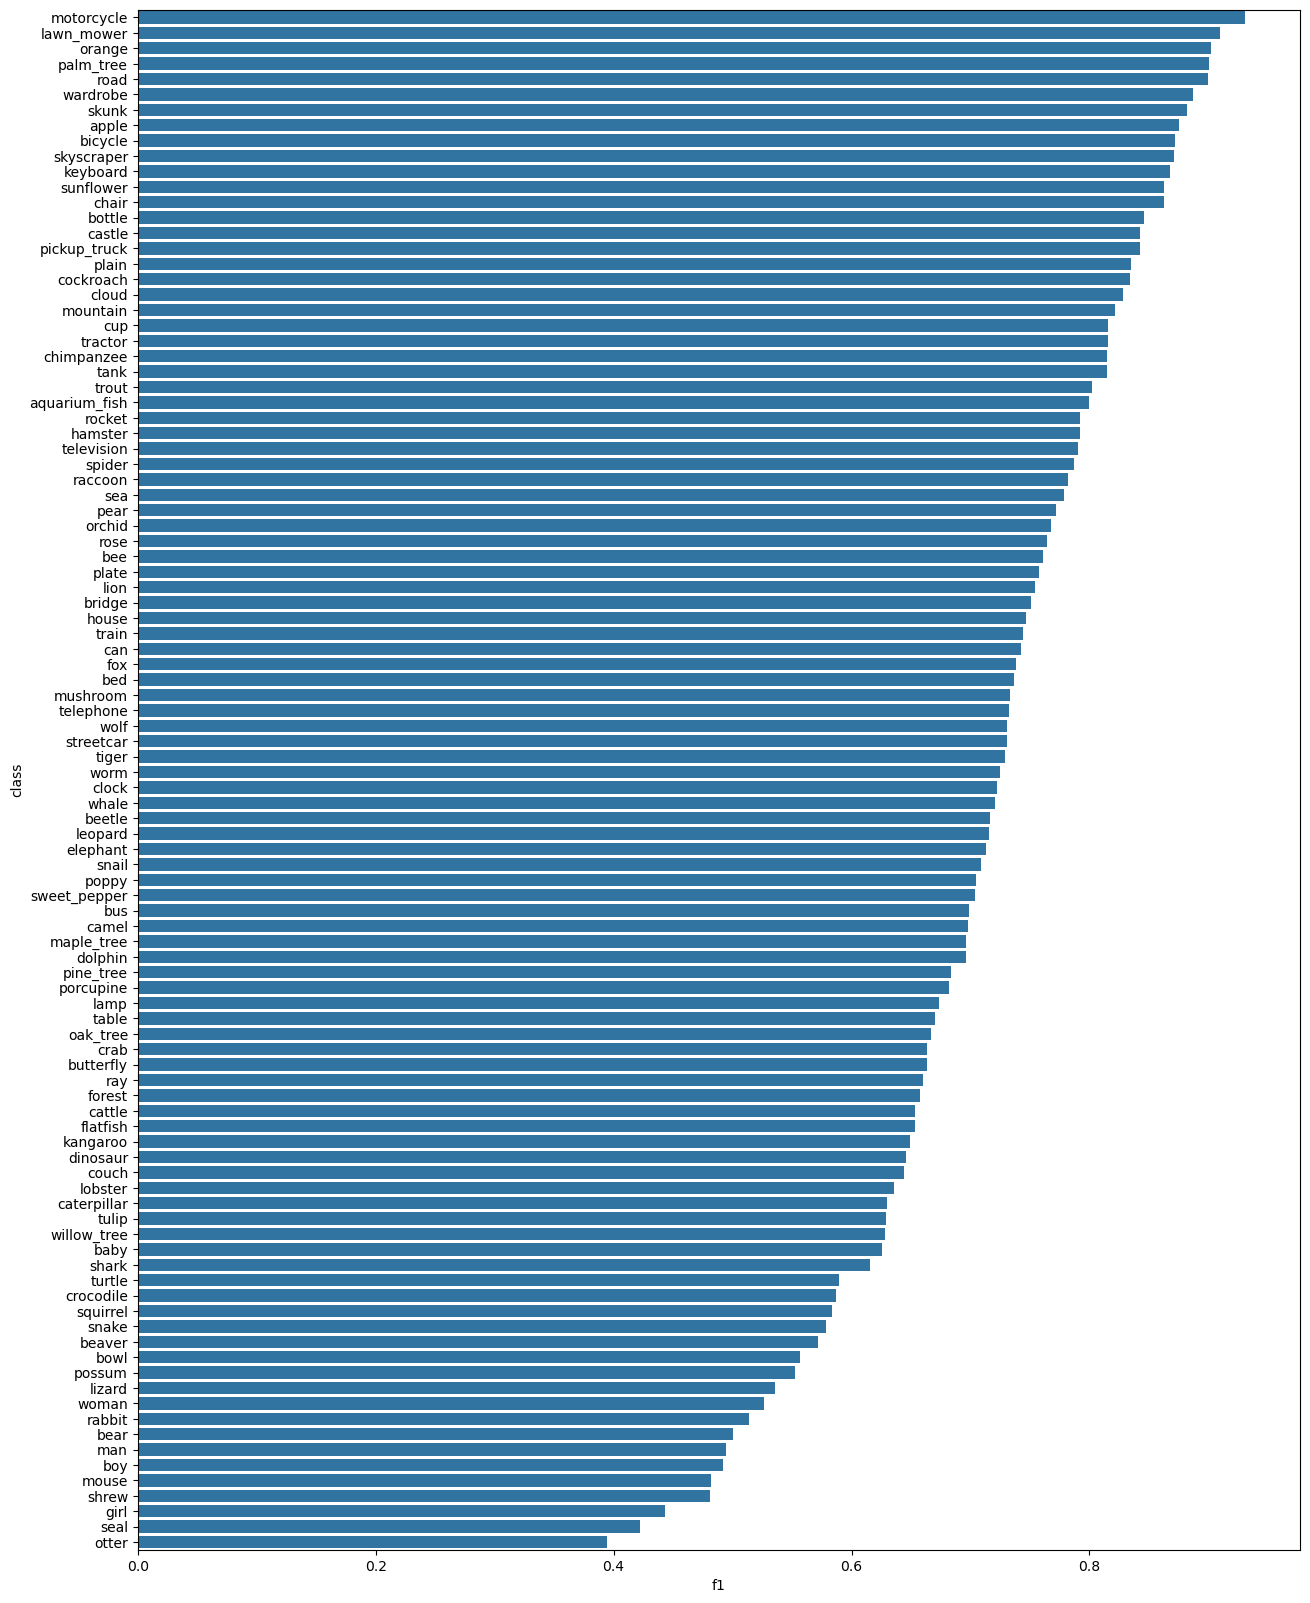

In [31]:
# Barplot for f1score dataframe

labels = list(class_labels.values())
f1_scores = f1_score(df_pred["Label Name"], df_pred["Predicted Name"], average=None, labels=labels)
f1_scores_with_labels = {label:score for label,score in zip(labels, f1_scores)}

f1_score_table = pd.DataFrame(list(f1_scores_with_labels.items()), columns=["class", "f1"])
f1_score_table = f1_score_table.sort_values(by="f1", ascending=False).reset_index(drop=True)

plt.figure(figsize=(15,20), dpi=100)
sns.barplot(x=f1_score_table["f1"], y=f1_score_table["class"])

In [32]:
# Save model

model.save('model.keras')